In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, sigmax, sigmaz, sesolve, expect
from scipy.integrate import quad

In [2]:
# Parameters
twopi = 2 * np.pi
anharmonicity = -0.3075 * twopi   # GHz
omega_d = 4.6040 * twopi          # Driving frequency in GHz
N = 2                     # Number of levels in the transmon
# # gamma = 0.05            # Dissipation rate
# T_lmsz = 400 * 1e-9 * 2/9                    # Pulse duration
# T_aeh = 800 * 1e-9 * 2/9                    # Pulse duration
# T_haeh = 800 * 1e-9 * 2/9                    # Pulse duration
# beta = 0.03
# tau = 127.33 * 1e-9 * 2/9
# sigma_lmsz = 127.33 * 1e-9 * 2/9
# sigma_aeh = 80 * 1e-9 * 2/9
# sigma_haeh = 160 * 1e-9 * 2/9
# P = 10
# T1 = T_lmsz / 100
# # Operators
# a = qutip.destroy(N)
# # H0 = omega_d * (a.dag() * a + 0.5 * qeye(N)) + anharmonicity * a.dag()**2 * a**2


In [3]:
# ----- Time-dependent coefficients (Landau–Zener-like) -----
def lmsz_pulse(t, args):
    """
    Rabi drive: constant amplitude A within [0, T]
    """
    A = args['A']
    T = args['T']
    # Heaviside window on [0, T]
    return A * (1.0 if (0.0 <= t <= T) else 0.0)

def lmsz_delta(t, args):
    """
    Linear detuning centered at T/2: Delta(t) = d * ((t - T/2)/sigma) on [0, T]
    """
    d = args['d']
    sigma = args['sigma']
    T = args['T']
    _T1 = args['T1']
    if 0.0 <= t <= T:
        return d * ((t - T/2.0 - _T1) / sigma)
    else:
        return 0.0

def aeh_pulse(t, args):
    """
    AEH pulse: Omega(t) = A * sech((t - T/2)/sigma) on t in [0, T], else 0
    """
    A = args['A']
    sigma = args['sigma']
    T = args['T']
    if not (0.0 <= t <= T):
        return 0.0
    x = (t - 0.5 * T) / sigma
    return A / np.cosh(x)

def aeh_delta(t, args):
    """
    AEH detuning: Delta(t) = d * tanh((t - T/2)/sigma) on t in [0, T], else 0
    """
    d = args['d']
    sigma = args['sigma']
    T = args['T']
    _T1 = args['T1']
    if not (0.0 <= t <= T):
        return 0.0
    x = (t - 0.5 * T - _T1) / sigma
    return d * np.tanh(x)

def haeh_pulse(t, args):
    """
    Half-AEH pulse: Omega(t) = A * sech((t - T)/sigma) on t in [0, T], else 0
    """
    A = args['A']
    sigma = args['sigma']
    T = args['T']
    if not (0.0 <= t <= T):
        return 0.0
    x = (t - T) / sigma
    return A / np.cosh(x)

def haeh_delta(t, args):
    """
    Half-AEH detuning: Delta(t) = d * tanh((t - T)/sigma) on t in [0, T], else 0
    """
    d = args['d']
    sigma = args['sigma']
    T = args['T']
    _T1 = args['T1']
    if not (0.0 <= t <= T):
        return 0.0
    x = (t - T - _T1) / sigma
    return d * np.tanh(x)

pulses = [lmsz_pulse, aeh_pulse, haeh_pulse]
deltas = [lmsz_delta, aeh_delta, haeh_delta]

In [4]:
# ----- Problem setup -----
# Pauli operators
sx = sigmax()
sz = sigmaz()

# Initial and measurement
g = basis(2, 0)       # ground |0>
e = basis(2, 1)       # excited |1>
Pe = e * e.dag()      # projector onto excited state

# Time parameters
T_lmsz = 400 * 2/9   
T_aeh = 800 * 2/9
T_haeh = 800 * 2/9
sigma_lmsz = 127.33 * 2/9
sigma_aeh = 80 * 2/9
sigma_haeh = 160 * 2/9
nt = 2001

Ts = [T_lmsz, T_aeh, T_haeh]
sigmas = [sigma_lmsz, sigma_aeh, sigma_haeh]
# Fixed offset detuning (unused in this minimal model, but kept for completeness)
delta0 = 0.0

In [5]:
def calculate_areas():
    def pa(sigma, T):
        return {'sigma': sigma, 'A': 1, 't0': T / 2, 'delta': 1 / (anharmonicity), 'd': 0, 'T': T, 'N': N}
    lmsz_area = quad(lambda t: lmsz_pulse(t, pa(sigma_lmsz, T_lmsz)), 0, T_lmsz, limit=1000)
    aeh_area = quad(lambda t: aeh_pulse(t, pa(sigma_aeh, T_aeh)), 0, T_aeh, limit=1000)
    haeh_area = quad(lambda t: haeh_pulse(t, pa(sigma_haeh, T_haeh)), 0, T_haeh, limit=1000)
    return lmsz_area, aeh_area, haeh_area
# lmsz = calculate_areas()
lmsz, aeh, haeh = calculate_areas()
lmsz_area, lmsz_area_err = lmsz
aeh_area, aeh_area_err = aeh
haeh_area, haeh_area_err = haeh
A_lmsz_max = 11.2 * np.pi / lmsz_area
A_aeh_max = 11.2 * np.pi / aeh_area
A_haeh_max = 10.2 * np.pi / haeh_area
A_lmsz_max, A_aeh_max, A_haeh_max

# Parameter sweeps
d_lmsz_max, d_aeh_max, d_haeh_max = (0.6, .25, .1)

Amaxs = [A_lmsz_max, A_aeh_max, A_haeh_max]
dmaxs = [d_lmsz_max, d_aeh_max, d_haeh_max]
idx = np.arange(3)
# A_values = np.linspace(0.0, A_lmsz_max, 81)     # Rabi amplitude (y-axis)
# d_values = np.linspace(-d_lmsz_max, d_lmsz_max, 101)    # detuning amplitude (x-axis)
# P_exc = np.zeros((len(A_values), len(d_values)))

In [6]:
# ----- Scan and simulate -----
P_exc = np.zeros((3, 81, 101))
for i, pulse, delta, T, sigma, Amax, dmax in zip(idx, pulses, deltas, Ts, sigmas, Amaxs, dmaxs):
    tlist = np.linspace(0.0, T, nt)
    A_values = np.linspace(0.0, Amax, 81)     # Rabi amplitude (y-axis)
    d_values = np.linspace(-dmax, dmax, 101)    # detuning amplitude (x-axis)
    H = [
        [0.5 * sx, pulse],
        [0.5 * sz, delta],
    ]
    for iA, A in enumerate(A_values):
        for jd, d in enumerate(d_values):
            args = dict(A=A, d=d, sigma=sigma, T=T, delta=delta0)
            result = sesolve(H, g, tlist, args=args, progress_bar=None)
            # Final excited-state probability at t = T
            P_exc[i, iA, jd] = expect(Pe, result.states[-1])


C:\Miniconda3\envs\quantum2\Lib\site-packages\qutip\solver\solver_base.py:479: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


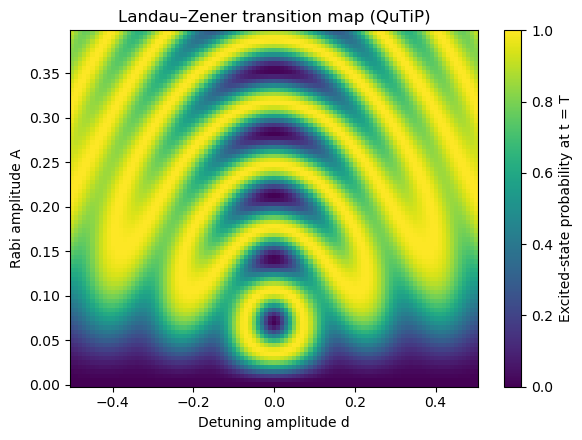

In [7]:
A_values, d_values = [], []
for i, Amax, dmax in zip(idx, Amaxs, dmaxs):
    A_values.append(np.linspace(0.0, Amax, 81))
    d_values.append(np.linspace(-dmax, dmax, 101))

# ----- Plot -----
fig, ax = plt.subplots(figsize=(6.0, 4.5))
mesh = ax.pcolormesh(d_values[0], A_values[0], P_exc[0], shading='auto', cmap='viridis')
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label('Excited-state probability at t = T')
ax.set_xlabel('Detuning amplitude d')
ax.set_ylabel('Rabi amplitude A')
ax.set_title('Landau–Zener transition map')
plt.tight_layout()
plt.show()


In [8]:
fig, ax = plt.subplots(figsize=(6.0, 4.5))
mesh = ax.pcolormesh(d_values[1], A_values[1], P_exc[1], shading='auto', cmap='viridis')
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label('Excited-state probability at t = T')
ax.set_xlabel('Detuning amplitude d')
ax.set_ylabel('Rabi amplitude A')
ax.set_title('Allen-Eberly transition map')
plt.tight_layout()
plt.show()


In [9]:
fig, ax = plt.subplots(figsize=(6.0, 4.5))
mesh = ax.pcolormesh(d_values[2], A_values[2], P_exc[2], shading='auto', cmap='viridis')
cbar = fig.colorbar(mesh, ax=ax)
# cbar.set_label('Excited-state probability at t = T')
ax.set_xlabel('Detuning amplitude d')
ax.set_ylabel('Rabi amplitude A')
ax.set_title('hAEH transition map')
plt.tight_layout()
plt.show()


In [10]:
import os
import pickle
from datetime import datetime
specific_name = "qiskit_experiments"

dt = datetime.now()
date_str = dt.strftime("%Y-%m-%d")
time_str = dt.strftime("%H%M%S")

folder = f"C:/Users/Ivo/Documents/{specific_name}/sims/time_dep_2lev/"
save_folder = f"{folder}/lz1_pulses/{date_str}/{time_str}"
os.makedirs(save_folder, exist_ok=True)
with open(os.path.join(save_folder, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(P_exc[0], f1)
with open(os.path.join(save_folder, "detunings.pkl"), "wb") as f1:
    pickle.dump(d_values[0], f1)
with open(os.path.join(save_folder, "areas.pkl"), "wb") as f1:
    pickle.dump(A_values[0], f1)


In [11]:
import os
import pickle
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/sims/time_dep_2lev/"
save_folder = f"{folder}/ae8_pulses/{date_str}/{time_str}"
os.makedirs(save_folder, exist_ok=True)
with open(os.path.join(save_folder, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(P_exc[1], f1)
with open(os.path.join(save_folder, "detunings.pkl"), "wb") as f1:
    pickle.dump(d_values[1], f1)
with open(os.path.join(save_folder, "areas.pkl"), "wb") as f1:
    pickle.dump(A_values[1], f1)


In [12]:
import os
import pickle
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/sims/time_dep_2lev/"
save_folder = f"{folder}/hae8_pulses/{date_str}/{time_str}"
os.makedirs(save_folder, exist_ok=True)
with open(os.path.join(save_folder, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(P_exc[2], f1)
with open(os.path.join(save_folder, "detunings.pkl"), "wb") as f1:
    pickle.dump(d_values[2], f1)
with open(os.path.join(save_folder, "areas.pkl"), "wb") as f1:
    pickle.dump(A_values[2], f1)


In [ ]:
# Simulation parameters
tlist_lmsz = np.linspace(0, T_lmsz, 15)  # Time grid
tlist_aeh = np.linspace(0, T_aeh, 15)  # Time grid
tlist_haeh = np.linspace(0, T_haeh, 15)  # Time grid
d_num = 46
A_min, A_num = (0, 45)
d_lmsz_max, d_aeh_max, d_haeh_max = (14.5e9, .25e9, .1e9)

# Run simulations
result_lmsz = run_simulation(lmsz_pulse, lmsz_delta, tlist_lmsz, sigma_lmsz, T_lmsz, -d_lmsz_max, d_lmsz_max, d_num, A_min, A_lmsz_max, A_num)
result_aeh = run_simulation(aeh_pulse, aeh_delta, tlist_aeh, sigma_aeh, T_aeh, -d_aeh_max, d_aeh_max, d_num, A_min, A_aeh_max, A_num)
result_haeh = run_simulation(haeh_pulse, haeh_delta, tlist_haeh, sigma_haeh, T_haeh, -d_haeh_max, d_haeh_max, d_num, A_min, A_haeh_max, A_num)

In [ ]:
d_range = np.linspace(-d_lmsz_max, d_lmsz_max, d_num)
A_lmsz_range = np.linspace(A_min, A_lmsz_max, A_num)
tr_probs_lmsz = np.array([[np.abs(r[1,1]) for r in res] for res in result_lmsz])[::-1]

# Create pcolormesh plot
fig, ax = plt.subplots(1,1)
cmap = matplotlib.colormaps["viridis"]  # Choose a colormap
im = ax.pcolormesh(d_range, A_lmsz_range, tr_probs_lmsz.T, vmin=0, vmax=1, cmap=cmap)
fig.colorbar(im, ax=ax, label='Transition Probability')
plt.ylabel('Rabi Frequency (1/T)')
plt.xlabel('Detuning (1/T)')
plt.title('Transition Probability for LMSZ Model')
plt.show()

In [ ]:
d_range = np.linspace(-d_aeh_max, d_aeh_max, d_num)
A_aeh_range = np.linspace(A_min, A_aeh_max, A_num)
tr_probs_aeh = np.array([[np.abs(r[1,1]) for r in res] for res in result_aeh])[::-1]

# Create pcolormesh plot
fig, ax = plt.subplots(1,1)
cmap = matplotlib.colormaps["viridis"]  # Choose a colormap
im = ax.pcolormesh(d_range, A_aeh_range, tr_probs_aeh.T, vmin=0, vmax=1, cmap=cmap)
fig.colorbar(im, ax=ax, label='Transition Probability')
plt.ylabel('Rabi Frequency (1/T)')
plt.xlabel('Detuning (1/T)')
plt.title('Transition Probability for AEH Model')
plt.show()

In [ ]:
d_range = np.linspace(-d_haeh_max, d_haeh_max, d_num)
A_haeh_range = np.linspace(A_min, A_haeh_max, A_num)
tr_probs_haeh = np.array([[np.abs(r[1,1]) for r in res] for res in result_haeh])[::-1]

# Create pcolormesh plot
fig, ax = plt.subplots(1,1)
cmap = matplotlib.colormaps["viridis"]  # Choose a colormap
im = ax.pcolormesh(d_range, A_haeh_range, tr_probs_haeh.T, vmin=0, vmax=1, cmap=cmap)
fig.colorbar(im, ax=ax, label='Transition Probability')
plt.ylabel('Rabi Frequency (1/T)')
plt.xlabel('Detuning (1/T)')
plt.title('Transition Probability for hAEH Model')
plt.show()

In [ ]:
import os
import pickle
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/data/kyiv/14/power_broadening (narrowing)"
folder_save = f"{folder}/lz1_pulses/sim"
with open(os.path.join(folder_save, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(tr_probs_lmsz, f1)
with open(os.path.join(folder_save, "detunings.pkl"), "wb") as f1:
    pickle.dump(np.linspace(-d_lmsz_max, d_lmsz_max, d_num), f1)
with open(os.path.join(folder_save, "areas.pkl"), "wb") as f1:
    pickle.dump(A_lmsz_range, f1)


In [ ]:
import os
import pickle
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/data/kyiv/14/power_broadening (narrowing)"
folder_save = f"{folder}/ae8_pulses/sim"
with open(os.path.join(folder_save, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(tr_probs_aeh, f1)
with open(os.path.join(folder_save, "detunings.pkl"), "wb") as f1:
    pickle.dump(np.linspace(-d_aeh_max, d_aeh_max, d_num), f1)
with open(os.path.join(folder_save, "areas.pkl"), "wb") as f1:
    pickle.dump(A_aeh_range, f1)


In [ ]:
import os
import pickle
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/data/kyiv/14/power_broadening (narrowing)"
folder_save = f"{folder}/hae8_pulses/sim"
with open(os.path.join(folder_save, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(tr_probs_haeh, f1)
with open(os.path.join(folder_save, "detunings.pkl"), "wb") as f1:
    pickle.dump(np.linspace(-d_haeh_max, d_haeh_max, d_num), f1)
with open(os.path.join(folder_save, "areas.pkl"), "wb") as f1:
    pickle.dump(A_haeh_range, f1)


In [ ]:
import numpy as np
import scqubits
from scipy.optimize import minimize
twopi = 2 * np.pi

In [ ]:
# Define the objective function to be optimized
def objective_function(params):
    transmon = scqubits.Transmon(EJ=params[0],
                                 EC=params[1],
                                 ng=0,
                                 ncut=31,
                                 truncated_dim=8)
    exc_energies = np.diff(transmon.eigenvals())
    anharm = np.diff(exc_energies)[0]
    return (exc_energies[0] - obj_energy)**2 + (anharm - obj_anharm)**2


In [ ]:
initial_guess = [10, 0.2]
obj_energy, obj_anharm = 4.6040 * twopi, -0.3075 * twopi
bounds = [(0, 100), (0, 100)]
result = minimize(objective_function, initial_guess, bounds=bounds)
# Print the optimization result
print("Optimization Result:")
print("Success:", result.success)
print("Message:", result.message)
print("Optimal Parameters:", result.x)
print("Objective Function Value at Optimum:", result.fun)

In [ ]:
transmon = scqubits.Transmon(
    
    EJ=71.10953541,  
    EC=1.65550678,
    ng=0,
    ncut=31,
    truncated_dim=8)    
exc_energies = np.diff(transmon.eigenvals())
anharm = np.diff(exc_energies)[0]
print(transmon.eigenvals())
print(exc_energies/(2*np.pi))
print(transmon.n_operator(True))
ham = np.diff(np.diag(transmon.hamiltonian(True))) + np.ones(7) * -5
ham = np.diag(np.insert(ham, 0, [0]))
print(ham)

In [ ]:
transmon = scqubits.Transmon(
    EJ=71.10953541,  
    EC=1.65550678,
    ng=0,
    ncut=31,
    truncated_dim=8
)    

H0 = np.insert(np.diff(np.diag(transmon.hamiltonian(True))) - obj_energy, 0, [0])
H0 = np.diag(H0)
#     H0 += np.diag(np.ones(8) * args["d"])

print(H0)

H1 = transmon.n_operator(True)
H1 /= H1[0,1]
H1 /= 2

print(H1)
# H2 = np.diag(np.ones(8))
H2 = np.diag(np.arange(8))
# H2[0,0] = 0
print(H2)

# H = [qutip.Qobj(H0), [qutip.Qobj(H1), pulse_func], [qutip.Qobj(H2), delta_func]]

# print(H)

In [ ]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

# Define transmon parameters
Ej = 13.30993317  # Josephson energy in GHz
Ec = 0.26147263   # Charging energy in GHz
ng = 0.0          # Offset charge
ncut = 31         # Charge basis truncation
trunc = 8         # Truncation of the transmon Hilbert space

# Create Transmon object
transmon = scq.Transmon(EJ=Ej, EC=Ec, ng=ng, ncut=ncut, truncated_dim=trunc)

# Calculate the eigenvalues (energy levels) and eigenvectors of the transmon Hamiltonian
evals, evecs = transmon.eigensys()

# Construct the Hamiltonian in the energy basis (diagonal matrix with eigenvalues)
H_energy_basis = np.diag(evals)

# Print the Hamiltonian in the energy basis
print("Hamiltonian in the energy basis (diagonal elements):")
for idx, energy in enumerate(np.diag(H_energy_basis)):
    print(f"Level {idx}: {energy:.4f} GHz")

# Verify if the diagonal elements are positive
are_positive = np.all(np.diag(H_energy_basis) > 0)
print(f"\nAll diagonal elements positive: {are_positive}")
print(f"\nAll diagonal elements positive: {np.diag(H_energy_basis)}")

# Plot the Hamiltonian diagonal elements
plt.plot(np.diag(H_energy_basis), 'o-')
plt.xlabel("State index")
plt.ylabel("Energy (GHz)")
plt.title("Hamiltonian in the Energy Basis (Diagonal Elements)")
plt.grid(True)
plt.show()